# Stochastic Simulator of Physical Performance
---
### El Objetivo
**Construir un simulador basado en el Método de Monte Carlo para predecir, no cuánto peso vas a perder, sino la probabilidad de alcanzar tu meta en un tiempo determinado, considerando el caos del mundo real.**

## Escenario de Simulacion

### Contexto
- Vamos a modelar un plan de 90 días de déficit calórico.
- La Meta Teórica: Un déficit de 500 kcal diarias.
- La Realidad (El Ruido): El déficit real diario será una variable aleatoria que sigue una Distribución Normal. Habrá días de 700 kcal de déficit (entrenaste muy duro) y días de solo 200 kcal (comiste un extra).
- Conversión: Sabemos que aproximadamente 7,700 kcal de déficit equivalen a 1 kg de grasa perdida

### Formulación
**Pérdida Total ($W$):** Es la suma de los 90 déficits diarios dividida por la constante energética.
$$W = \frac{1}{7700} \sum_{i=1}^{90} \text{Deficit}_i$$
**La CDF ($F(x)$):** Nos da la probabilidad de que la pérdida total sea menor o igual a un valor $x$. Para saber la probabilidad de perder más de $x$ kilos, usaremos el complemento: $1 - F(x)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Definimos los parametros

In [5]:
dias = 90
simulaciones = 10000
media_deficit_diario =500
std_deficit = 150
calorias_por_kg = 7700
np.random.seed(42)

## Simulador de Monte Carlo

Iniciando simulacion de 10000 futuros posibles


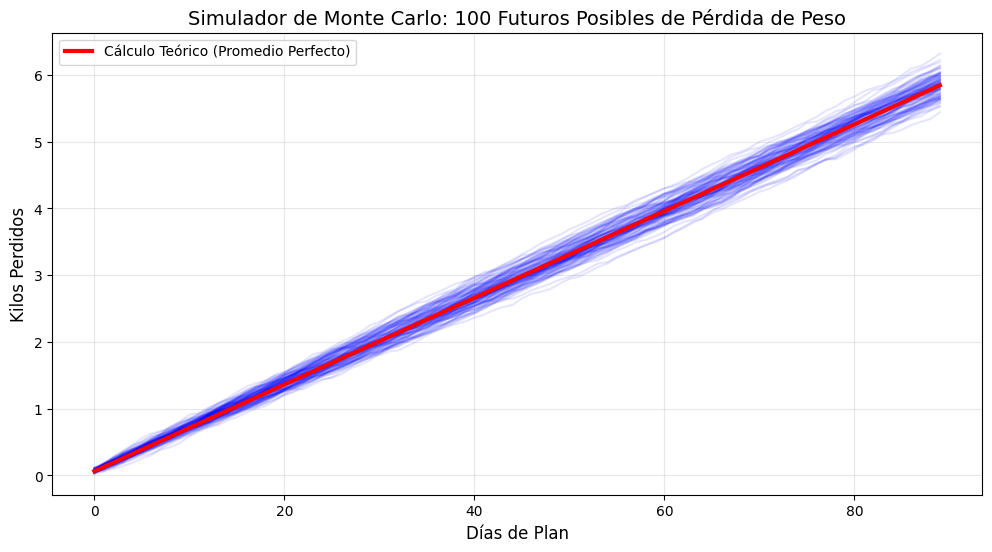


--- Resultados del Día 90 ---
Pérdida promedio esperada: 5.84 kg
El peor escenario (Mínima pérdida): 5.20 kg
El mejor escenario (Máxima pérdida): 6.55 kg


In [7]:
print(f"Iniciando simulacion de {simulaciones} futuros posibles")

# Creamos una matriz gigante  : 10000 filas (simulaciones) x 90 columnas (dias)
#Cada celda es una muestra sacada de nuestra Distribución Normal PDF
matriz_deficits = np.random.normal(media_deficit_diario, std_deficit, (simulaciones, dias))

#Calculamos la suma acumulada dia por dia para ver el progreso en el tiempo
# axis = 1 ,sumamos a lo largo de los dias por cada simulacion
deficit_acumulado = np.cumsum(matriz_deficits, axis=1)

#Convertimos las calorias a kg de peso perdido
peso_perdido_acumulado = deficit_acumulado / calorias_por_kg

#Resultados finales despues de 90 dias
peso_perdido_final = peso_perdido_acumulado[:,-1]

#Visualizamos los resultados

plt.figure(figsize=(12, 6))

# Dibujamos solo los primeros 100 universos para no saturar el gráfico
for i in range(100):
    plt.plot(peso_perdido_acumulado[i, :], color='blue', alpha=0.1)

# Dibujamos el escenario "Ideal" (Sin matemáticas estocásticas, solo promedio)
escenario_ideal = (np.arange(1, dias + 1) * media_deficit_diario) / calorias_por_kg
plt.plot(escenario_ideal, color='red', linewidth=3, label='Cálculo Teórico (Promedio Perfecto)')

plt.title("Simulador de Monte Carlo: 100 Futuros Posibles de Pérdida de Peso", fontsize=14)
plt.xlabel("Días de Plan", fontsize=12)
plt.ylabel("Kilos Perdidos", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n--- Resultados del Día 90 ---")
print(f"Pérdida promedio esperada: {np.mean(peso_perdido_final):.2f} kg")
print(f"El peor escenario (Mínima pérdida): {np.min(peso_perdido_final):.2f} kg")
print(f"El mejor escenario (Máxima pérdida): {np.max(peso_perdido_final):.2f} kg")


## De Datos a Decisión

**Ahora mismo tenemos un montón de datos (10,000 resultados), pero a un cliente o a un director de empresa no le das 10,000 números; le das una Garantía Probabilística.**

### Necesitamos responder a preguntas de negocio o personales precisas:
- "¿Cuál es la probabilidad EXACTA de perder más de 5 kg?"
- "¿Cuál es el mínimo de kilos que perderé con un 95% de seguridad?"

## Analitica de Decision

In [10]:
meta_kilos = 5.0

#CDF en accion 
#Calculamos la probabilidad empirica P(X >= 5) Kg 
prob_exito = np.mean(peso_perdido_final >= meta_kilos) * 100

#Intervalo de confianza al 90%
p05 = np.percentile(peso_perdido_final, 5) #El peor escenario del 5% de los universos
p95 = np.percentile(peso_perdido_final, 95)#El mejor escenario del 5% de los universos



## Visualizacion

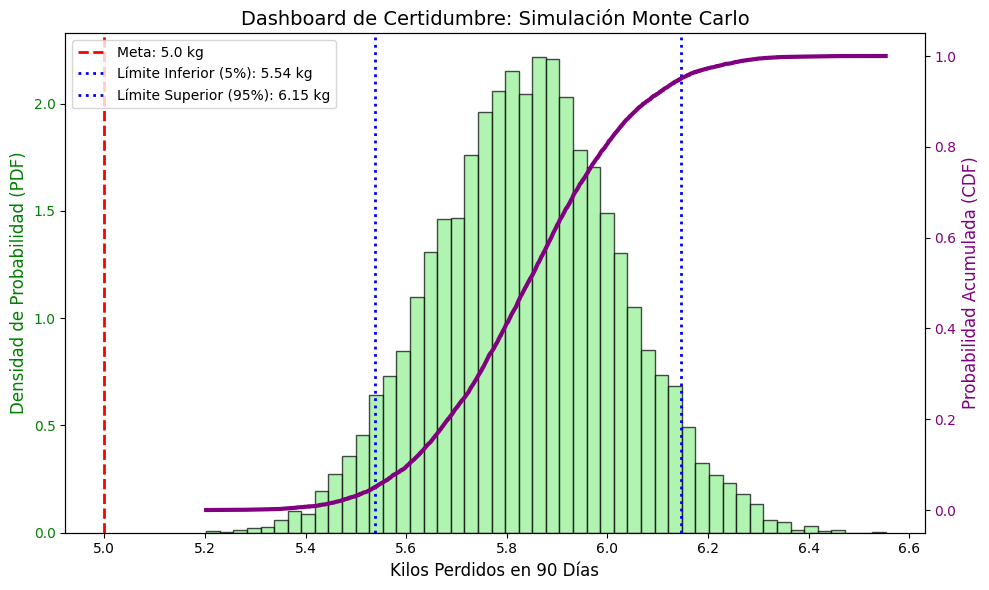

--- REPORTE ESTADÍSTICO ---
Objetivo: Perder 5.0 kg en 90 días.
Probabilidad de éxito P(X >= 5.0): 100.0%
Rango de Certeza (90%): Perderás entre 5.54 kg y 6.15 kg.


In [11]:

fig, ax1 = plt.subplots(figsize=(10, 6))

# Dibujamos el Histograma (La Función de Densidad - PDF empírica)
ax1.hist(peso_perdido_final, bins=50, color='lightgreen', edgecolor='black', alpha=0.7, density=True)
ax1.set_xlabel('Kilos Perdidos en 90 Días', fontsize=12)
ax1.set_ylabel('Densidad de Probabilidad (PDF)', color='green', fontsize=12)
ax1.tick_params(axis='y', labelcolor='green')

# Líneas críticas de decisión
ax1.axvline(meta_kilos, color='red', linestyle='--', linewidth=2, label=f'Meta: {meta_kilos} kg')
ax1.axvline(p05, color='blue', linestyle=':', linewidth=2, label=f'Límite Inferior (5%): {p05:.2f} kg')
ax1.axvline(p95, color='blue', linestyle=':', linewidth=2, label=f'Límite Superior (95%): {p95:.2f} kg')
ax1.legend(loc='upper left')

# Superponemos la Curva CDF en un segundo eje Y
ax2 = ax1.twinx()
x_cdf = np.sort(peso_perdido_final)
y_cdf = np.arange(1, len(x_cdf) + 1) / len(x_cdf) # Construcción manual de la CDF
ax2.plot(x_cdf, y_cdf, color='purple', linewidth=3, label='CDF (Probabilidad Acumulada)')
ax2.set_ylabel('Probabilidad Acumulada (CDF)', color='purple', fontsize=12)
ax2.tick_params(axis='y', labelcolor='purple')

plt.title('Dashboard de Certidumbre: Simulación Monte Carlo', fontsize=14)
fig.tight_layout()
plt.show()

# --- EL Veredicto del Modelo ---
print(f"--- REPORTE ESTADÍSTICO ---")
print(f"Objetivo: Perder {meta_kilos} kg en 90 días.")
print(f"Probabilidad de éxito P(X >= {meta_kilos}): {prob_exito:.1f}%")
print(f"Rango de Certeza (90%): Perderás entre {p05:.2f} kg y {p95:.2f} kg.")